In [1]:
import pandas as pd

full_dataset = pd.read_csv("features.csv")

print(full_dataset.head())

train_dataset = full_dataset.sample(frac=0.8, random_state=42)
test_dataset = full_dataset.drop(train_dataset.index)

   packet_size  ttl  protocol  src_port  dst_port  flags  tcp_window  \
0     0.475728  0.0       0.0  0.007286  0.986448   0.96    0.015595   
1     0.503467  0.0       0.0  0.007286  0.741094   0.64    0.007523   
2     0.015257  0.0       0.0  0.741094  0.007286   0.64    0.016541   
3     0.503467  0.0       0.0  0.007286  0.741094   0.96    0.007523   
4     0.503467  0.0       0.0  0.007286  0.741094   0.64    0.007523   

   payload_size  
0      0.464986  
1      0.492997  
2      0.000000  
3      0.492997  
4      0.492997  


In [2]:
# Write a autoencoder net with binary intermediate layers

import torch
import torch.nn as nn


class BinarizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        out = torch.sign(x)
        out[out == 0] = 1
        return out

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        mask = (x.abs() <= 1).float()
        return grad_output * mask


def binarize(x):
    return BinarizeSTE.apply(x)


class BinaryHiddenLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x):
        return binarize(self.linear(x))


class BinaryAutoencoder(nn.Module):
    def __init__(self, input_size=8, hidden_size=48, number_hidden_layers=2,latent_size=8):
        super().__init__()

        self.encoder = nn.Sequential(
            BinaryHiddenLayer(input_size, hidden_size),
            *[BinaryHiddenLayer(hidden_size, hidden_size) for _ in range(number_hidden_layers - 1)],
            BinaryHiddenLayer(hidden_size, latent_size),
        )

        self.decoder = nn.Sequential(
            BinaryHiddenLayer(latent_size, hidden_size),
            *[BinaryHiddenLayer(hidden_size, hidden_size) for _ in range(number_hidden_layers - 1)],
            nn.Linear(hidden_size, input_size),
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction, latent


In [7]:
import numpy as np
import tqdm

MAX_LAYERS = 8
MAX_HIDDEN_SIZE = 16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x = torch.tensor(train_dataset.to_numpy(dtype=np.float32)).to(device)
def train_test_model(data, size, number_hidden_layers=2):
    model = BinaryAutoencoder(input_size=data.shape[1], hidden_size=size*4, number_hidden_layers=number_hidden_layers, latent_size=size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epochs = 5000
    pbar = tqdm.tqdm(range(epochs))
    losses = []
    for epoch in pbar:
        optimizer.zero_grad()
        reconstruction, latent = model(x)
        loss = torch.nn.functional.mse_loss(reconstruction, x)
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=loss.item())
        losses.append(loss.item())
    return sum(losses)/len(losses)

measured_losses = []

for i in range(1, MAX_LAYERS + 1):
    print(f"Training models with {i} hidden layers")
    for j in range(1, MAX_HIDDEN_SIZE + 1):
        print(f"\tTraining model with latent size {j} and hidden size {j*4}")
        loss = train_test_model(x, j, number_hidden_layers=i)
        measured_losses.append((i, j, loss))
        print(f"\tFinal loss for latent size {j} and hidden size {j*4}: {loss}")

Using device: cuda
Training models with 1 hidden layers
	Training model with latent size 1 and hidden size 4


100%|██████████| 5000/5000 [02:20<00:00, 35.57it/s, loss=0.0182]


	Final loss for latent size 1 and hidden size 4: 0.04655292898118496
	Training model with latent size 2 and hidden size 8


100%|██████████| 5000/5000 [01:10<00:00, 71.05it/s, loss=0.0119]


	Final loss for latent size 2 and hidden size 8: 0.022446701087988914
	Training model with latent size 3 and hidden size 12


...

	Final loss for latent size 14 and hidden size 56: 0.02066532676462084
	Training model with latent size 15 and hidden size 60


100%|██████████| 5000/5000 [04:05<00:00, 20.39it/s, loss=0.0155]


	Final loss for latent size 15 and hidden size 60: 0.0238892701536417
	Training model with latent size 16 and hidden size 64


100%|██████████| 5000/5000 [04:05<00:00, 20.36it/s, loss=0.0237] 

	Final loss for latent size 16 and hidden size 64: 0.022083447296917438


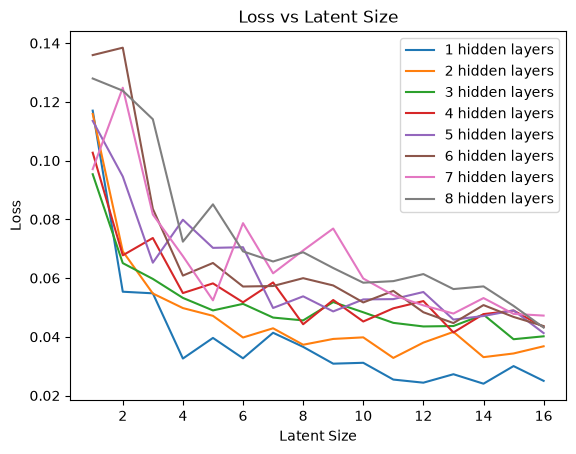

In [5]:
from matplotlib import pyplot as plt

for i in range(1, MAX_LAYERS + 1):
    losses_for_layer = [loss for layer, size, loss in measured_losses if layer == i]
    plt.plot(range(1, MAX_HIDDEN_SIZE + 1), losses_for_layer, label=f"{i} hidden layers")
plt.xlabel("Latent Size")
plt.ylabel("Loss")
plt.title("Loss vs Latent Size")
plt.legend()
plt.show()